In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [6]:
df=pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\Salary_dataset.csv")

In [7]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [9]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [10]:
df = df.drop(columns=["Unnamed: 0"])

In [11]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [12]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

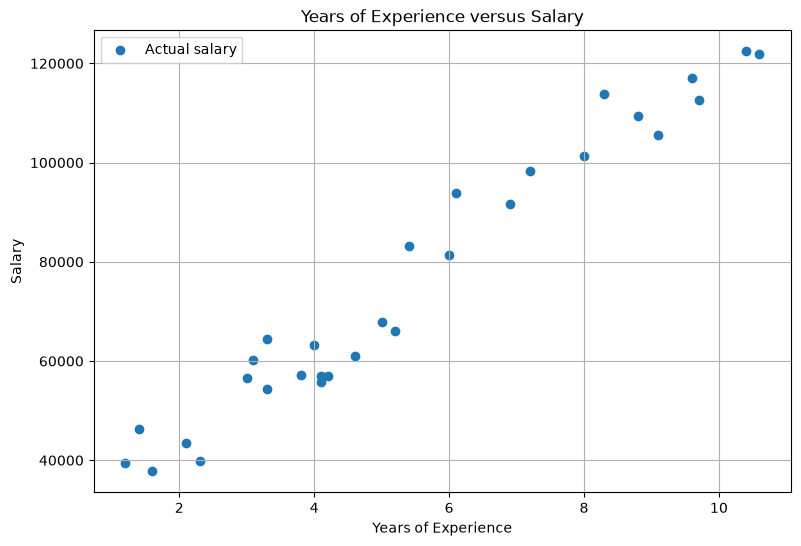

In [13]:
plt.figure(figsize=(9, 6))
plt.scatter(
df["YearsExperience"],
df["Salary"],
label="Actual salary"
)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience versus Salary")
plt.grid(True)
plt.legend()
plt.show()

In [14]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [15]:
model = LinearRegression()

In [16]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9449.96]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.485e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [17]:
intercept = model.intercept_
slope = model.coef_[0]
print(f"Intercept: {intercept:.2f}")
print(f"Slope: {slope:.2f}")

Intercept: 24848.20
Slope: 9449.96


In [19]:
y_pred = model.predict(X)

In [20]:
results = pd.DataFrame({
"YearsExperience": df["YearsExperience"],
"ActualSalary": y,
"PredictedSalary": y_pred
})
results["Residual"] = (
results["ActualSalary"] - results["PredictedSalary"]
)
results.head()

,YearsExperience,ActualSalary,PredictedSalary,Residual
0,1.2,39344.0,36188.158752,3155.841248
1,1.4,46206.0,38078.151217,8127.848783
2,1.6,37732.0,39968.143681,-2236.143681
3,2.1,43526.0,44693.124842,-1167.124842
4,2.3,39892.0,46583.117306,-6691.117306


In [21]:
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Mean Squared Error: 31270951.72
Root Mean Squared Error: 5592.04


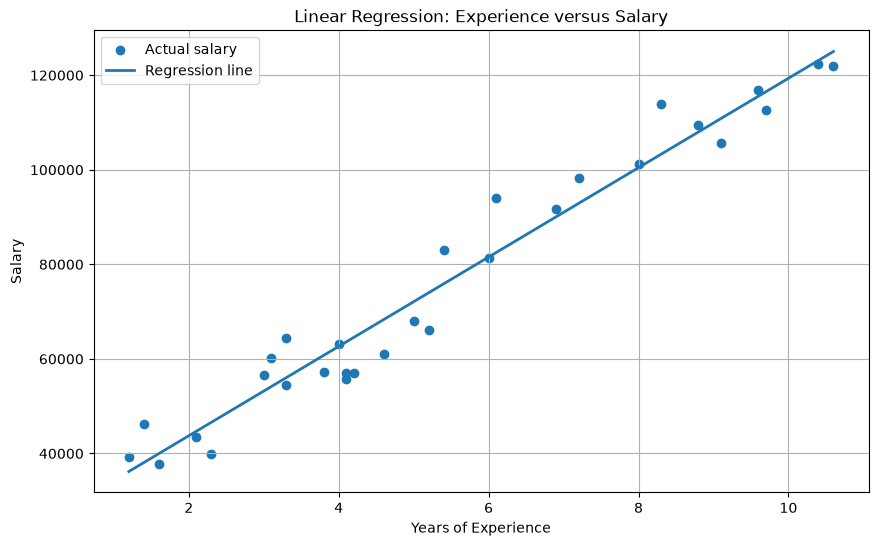

In [22]:
plot_data = results.sort_values("YearsExperience")
plt.figure(figsize=(10, 6))
plt.scatter(
results["YearsExperience"],
results["ActualSalary"],
label="Actual salary"
)
plt.plot(
plot_data["YearsExperience"],
plot_data["PredictedSalary"],
linewidth=2,
label="Regression line"
)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Experience versus Salary")
plt.grid(True)
plt.legend()
plt.show()

In [23]:
new_employee = pd.DataFrame({
"YearsExperience": [6.0]
})
predicted_salary = model.predict(new_employee)
print(
f"Predicted salary for 6 years of experience: "
f"{predicted_salary[0]:.2f}"
)

Predicted salary for 6 years of experience: 81547.98
